# Cross-fitted information between continuous $X$ and binary choice $R$

This notebook estimates the predictive-information lower bound

$$
\widehat I_q(X;R)=\widehat H(R)+\frac{1}{N}\sum_i \log_2 q_{-i}(r_i\mid x_i)
=\widehat H(R)-\widehat{\mathrm{CE}}_{\mathrm{OOF}}(q),
$$

where every $q_{-i}$ is selected and fitted without observation $i$. In the population,

$$
I(X;R)-I_q(X;R)=\mathbb E_X D_{\mathrm{KL}}\!\left[p(R\mid X)\,\Vert\,q(R\mid X)\right]\ge 0.
$$

Thus this does **not** assume that the decision-maker uses $p(y\mid x)$. It models choice directly. The finite-sample plug-in estimate can be negative and is not a formal confidence bound; the second public function quantifies its sampling and model-selection uncertainty by rerunning the complete pipeline.

The reusable implementation is in `choice_information.py` beside this notebook. Keeping it in a module makes the functions importable by other analyses and keeps this notebook readable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from choice_information import (
    default_model_library,
    estimate_choice_information,
    bootstrap_choice_information,
    plot_choice_information_diagnostics,
    plot_bootstrap_choice_information,
)

pd.set_option("display.max_columns", 30)

## Public function 1: point estimate and diagnostics

`estimate_choice_information(X, R, ...)` accepts four outer-fold modes:

- `fold_mode="random"`: shuffled stratified folds.
- `fold_mode="intervals"`: automatic contiguous folds, explicit half-open `(start, stop)` intervals, or one interval label per row.
- `fold_mode="indices"`: one arbitrary fold label per row, or a list of disjoint test-index arrays.
- `fold_mode="groups"`: an additional convenience that keeps sessions, stimulus identities, or other clusters intact.

Within every outer training set, inner CV selects the candidate with the best log loss. The default library contains regularized logistic regression, an additive spline-logistic model (when dimensionality is reasonable), and shallow histogram gradient boosting. Imputation, scaling, spline construction, model selection, and fitting all occur inside the folds.

The primary output is `mi_lower_bound_bits`. The intercept-only held-out score is a diagnostic rather than part of the lower-bound formula. `cv_log_score_gain_vs_intercept_bits` is often close to the primary estimate, but they are intentionally kept separate.

In [2]:
help(estimate_choice_information)

Help on function estimate_choice_information in module choice_information:

estimate_choice_information(X: 'Any', R: 'Any', *, fold_mode='random', n_splits=5, inner_n_splits=3, intervals=None, fold_indices=None, fold_groups=None, model_library: 'Sequence[tuple[str, BaseEstimator]] | None' = None, random_state=2026, reliability_bins=10, return_estimators=False, plot=False)
    Estimate H_hat(R) - held-out CE(q) with nested cross-fitting.
    
    ``fold_mode`` may be ``random``, ``intervals``, ``indices``, or ``groups``.
    For intervals, pass half-open ``[(start, stop), ...]`` or omit them for
    automatic contiguous folds. For indices, pass one fold label per row or a
    list of test-index arrays. For groups, pass one group ID per row.
    
    Model choice and all preprocessing occur inside each outer training set.
    The population analogue is a variational lower bound on I(X;R); this sample
    estimate may be negative and requires uncertainty analysis.



## Synthetic example

Replace `X` and `R` below with one subject's arrays. This example contains linear, nonlinear, and interaction structure without referring to a latent variable.

In [3]:
rng = np.random.default_rng(2026)
n_trials = 600
X = rng.normal(size=(n_trials, 4))
choice_log_odds = (
    1.35 * X[:, 0]
    - 0.65 * X[:, 1]
    + 0.75 * (X[:, 2] ** 2 - 1.0)
    + 0.50 * X[:, 0] * X[:, 3]
)
p_choice = 1.0 / (1.0 + np.exp(-choice_log_odds))
R = rng.binomial(1, p_choice)

X.shape, np.bincount(R)

((600, 4), array([304, 296]))

In [4]:
result = estimate_choice_information(
    X,
    R,
    fold_mode="random",
    n_splits=5,
    inner_n_splits=3,
    random_state=2026,
)

summary = pd.Series({
    "I lower bound (bits/trial)": result["mi_lower_bound_bits"],
    "H(R) (bits/trial)": result["response_entropy_bits"],
    "OOF conditional cross-entropy": result["conditional_cross_entropy_bits"],
    "OOF intercept cross-entropy": result["intercept_cv_cross_entropy_bits"],
    "OOF gain vs intercept": result["cv_log_score_gain_vs_intercept_bits"],
    "Brier score": result["brier_score"],
    "ROC AUC": result["roc_auc"],
    "expected calibration error": result["expected_calibration_error"],
    "descriptive calibration intercept": result["calibration_intercept_descriptive"],
    "descriptive calibration slope": result["calibration_slope_descriptive"],
})
summary.to_frame("value")

,value
I lower bound (bits/trial),0.250405
H(R) (bits/trial),0.999872
OOF conditional cross-entropy,0.749466
OOF intercept cross-entropy,0.999890
OOF gain vs intercept,0.250423
Brier score,0.172196
ROC AUC,0.819857
expected calibration error,0.053182
descriptive calibration intercept,-0.015280
descriptive calibration slope,0.908121


In [5]:
result["per_fold"]

,outer_fold,n_train,n_test,test_response_rate,selected_model,best_inner_log_loss_bits,model_test_log_loss_bits,intercept_test_log_loss_bits,test_log_score_gain_bits
0,0,480,120,0.491667,additive_spline_logistic,0.789955,0.751601,0.999812,0.248211
1,1,480,120,0.491667,additive_spline_logistic,0.764752,0.769434,0.999812,0.230379
2,2,480,120,0.491667,additive_spline_logistic,0.760195,0.772168,0.999812,0.227644
3,3,480,120,0.491667,additive_spline_logistic,0.735371,0.781155,0.999812,0.218657
4,4,480,120,0.500000,additive_spline_logistic,0.792121,0.672974,1.000200,0.327226


In [6]:
result["model_selection_counts"].to_frame()

,outer_folds_selected
additive_spline_logistic,5


In [7]:
result["reliability"]

,n,mean_predicted,observed_rate,min_predicted,max_predicted,abs_calibration_error
0,60,0.074013,0.150000,0.009736,0.111713,0.075987
1,60,0.152534,0.233333,0.112050,0.183224,0.080799
2,60,0.221093,0.150000,0.184588,0.253282,0.071093
3,60,0.310177,0.216667,0.257342,0.358445,0.093510
4,60,0.421557,0.483333,0.360258,0.486568,0.061777
5,60,0.542390,0.550000,0.489188,0.595423,0.007610
6,60,0.662463,0.600000,0.596182,0.714175,0.062463
7,60,0.757087,0.716667,0.716054,0.799207,0.040421
8,60,0.851758,0.883333,0.800984,0.908426,0.031575
9,60,0.956590,0.950000,0.909914,0.999945,0.006590


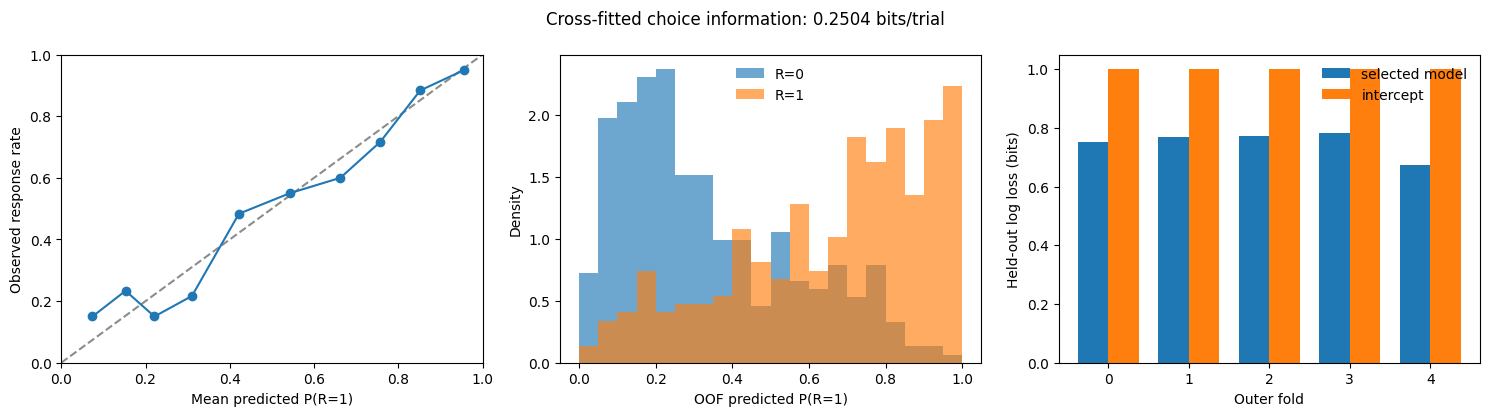

In [8]:
plot_choice_information_diagnostics(result)
plt.show()

## Choosing folds

These examples are not executed because each would rerun nested model selection. Uncomment the one matching the scientific generalization target. All supplied folds must cover every row exactly once. For serially dependent data, contiguous intervals or intact session groups are generally preferable to random folds.

In [9]:
# 1. Automatic contiguous intervals
# interval_result = estimate_choice_information(
#     X, R, fold_mode="intervals", n_splits=5
# )

# 2. Explicit half-open intervals
explicit_intervals = [(0, 120), (120, 240), (240, 360), (360, 480), (480, 600)]
# interval_result = estimate_choice_information(
#     X, R, fold_mode="intervals", intervals=explicit_intervals
# )

# 3. Arbitrary fold labels (equivalently, pass a list of test-index arrays)
arbitrary_fold_labels = np.arange(n_trials) % 5
# arbitrary_result = estimate_choice_information(
#     X, R, fold_mode="indices", fold_indices=arbitrary_fold_labels
# )

# 4. Intact groups -- here, 20 synthetic sessions of 30 trials
session_id = np.repeat(np.arange(20), 30)
# grouped_result = estimate_choice_information(
#     X, R, fold_mode="groups", fold_groups=session_id, n_splits=5
# )

## Public function 2: full-pipeline bootstrap uncertainty

`bootstrap_choice_information` first obtains the point estimate, then resamples trials or whole clusters and reruns outer cross-fitting, inner model selection, preprocessing, and fitting in every replicate. Repeated copies of an original trial or cluster are assigned to the same outer fold, avoiding direct duplicate leakage between train and test data.

The short run below is only a computational smoke test. For the final analysis, use at least 500 replicates (often 1,000) and resample the highest-level approximately independent unit. Use `n_jobs=-1` only if the machine has enough memory. Percentile intervals describe pipeline sampling variability; they do not convert the variational estimate into a formal lower confidence bound on true MI.

In [10]:
uncertainty = bootstrap_choice_information(
    X,
    R,
    n_bootstrap=8,  # use 500-1000 for the final analysis
    confidence=0.95,
    estimator_kwargs={
        "fold_mode": "random",
        "n_splits": 5,
        "inner_n_splits": 3,
        "random_state": 2026,
    },
    random_state=2027,
    n_jobs=1,
)

pd.Series({
    "point estimate": uncertainty["point_mi_lower_bound_bits"],
    "bootstrap SE": uncertainty["bootstrap_standard_error_bits"],
    "CI lower": uncertainty["percentile_ci_bits"][0],
    "CI upper": uncertainty["percentile_ci_bits"][1],
    "bootstrap bias": uncertainty["bootstrap_bias_bits"],
    "successful replicates": uncertainty["n_bootstrap_successful"],
}).to_frame("bits (except count)")

,bits (except count)
point estimate,0.250405
bootstrap SE,0.037806
CI lower,0.141648
CI upper,0.242759
bootstrap bias,-0.056493
successful replicates,8.000000


In [11]:
uncertainty["bootstrap_samples"]

,replicate,mi_lower_bound_bits,conditional_cross_entropy_bits,cv_log_score_gain_vs_intercept_bits,brier_score,error
0,0,0.179076,0.820635,0.180137,0.188570,
1,1,0.244751,0.755177,0.248433,0.173864,
2,2,0.139652,0.858544,0.141460,0.189931,
3,3,0.233367,0.765663,0.235890,0.171348,
4,4,0.211504,0.785601,0.214084,0.179185,
5,5,0.151060,0.845057,0.152569,0.192905,
6,6,0.179433,0.820174,0.180730,0.185750,
7,7,0.212453,0.786577,0.215675,0.179074,


In [12]:
uncertainty["bootstrap_model_selection_counts"].to_frame()

,outer_folds_selected
additive_spline_logistic,19
logistic_l2_C=1,12
logistic_l2_C=0.1,6
hist_gradient_boosting_leaves=7,3


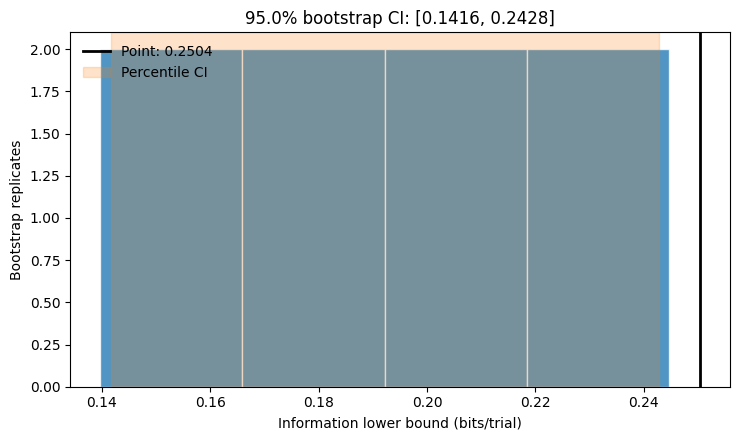

In [13]:
plot_bootstrap_choice_information(uncertainty)
plt.show()

### Cluster bootstrap example

For sessions or stimulus clusters, pass one group label per row. The point estimator should normally also use group-aware folds when those units must remain independent. This example is left unexecuted because a production cluster bootstrap is intentionally expensive.

In [14]:
# session_uncertainty = bootstrap_choice_information(
#     X,
#     R,
#     n_bootstrap=1000,
#     resample_groups=session_id,
#     estimator_kwargs={
#         "fold_mode": "groups",
#         "fold_groups": session_id,
#         "n_splits": 5,
#         "inner_n_splits": 3,
#     },
#     n_jobs=-1,
# )

## Reporting and checks

A concise report should include the primary estimate in bits/trial, bootstrap interval, response entropy, held-out intercept comparison, fold definition, candidate library, and model-selection frequencies.

Useful safeguards:

- The theoretical range is $0\le I(X;R)\le H(R)\le 1$ bit. A negative sample estimate means the selected predictor did worse than the entropy benchmark; retain it rather than truncating it.
- Inspect foldwise scores. A result driven by one interval/session may not generalize.
- Calibration matters because this is based on log probabilities, not classification accuracy. The calibration intercept/slope here are descriptive fits to all OOF predictions, not independently validated recalibrations.
- If probability calibration is added, it must be another inner-training operation. Never fit it on an outer test fold.
- Bootstrap trials only when trials are plausibly independent. Otherwise resample sessions, blocks, participants, or repeated-stimulus identities as appropriate.
- A permutation-null analysis is a valuable separate leakage check: permute responses within exchangeability blocks and rerun the entire pipeline.